# Proyek Analisis Data: Sistem Rekomendasi Jurusan Untuk Siswa-Siswi Berbasis Minat dan Kemampuan



# Menentukan Pertanyaan Bisnis


**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memperoleh informasi yang mendalam.

**Specific (Spesifik)**
Pertanyaan harus jelas, fokus pada topik tertentu, dan tidak bermakna ganda.
- Salah: Jurusan apa yang cocok untuk siswa?
- Benar: Nilai mata pelajaran apa yang paling berkorelasi dengan pemilihan jurusan tertentu berdasarkan data 6.000 siswa?

**Measurable (Terukur)**
Pertanyaan harus bisa dijawab dengan angka atau metrik yang konkret
- Salah: Apakah nilai siswa memengaruhi pilihan jurusan?
- Benar: Berapa rata-rata nilai matematika, fisika, dan kimia pada siswa yang memiliki aspirasi karier di bidang sains dibandingkan bidang sosial?

**Action-Oriented (Berorientasi Aksi)**
Hasil pertanyaan harus bisa memberikan arahan untuk tindakan nyata
- Salah: Mengapa siswa sulit memilih jurusan?
- Benar: Fitur nilai mata pelajaran mana yang harus dijadikan input wajib pada form website agar model rekomendasi menghasilkan prediksi jurusan yang paling akurat?

**Relevant (Relevan)**
- Salah: Menanyakan metode belajar saat masalah utamanya adalah ketepatan rekomendasi jurusan
- Benar: Apakah nilai akademik cukup diskriminatif untuk membedakan kelompok aspirasi karier siswa?

**Time-bound (Terikat Waktu)**
- Salah: Berapa banyak siswa yang salah jurusan?
- Benar: Berdasarkan data historis 6.000 siswa dalam dataset, seberapa besar gap rata-rata nilai antar kelompok aspirasi karier?


**Pertanyaan 1:**
Nilai mata pelajaran mana (matematika, fisika, kimia, biologi, sejarah, geografi, bahasa Inggris) yang memiliki korelasi tertinggi antar satu sama lain, dan mana yang paling diskriminatif terhadap kelompok aspirasi karier siswa berdasarkan data 6.000 siswa dalam dataset student-scores-6k?

**Pertanyaan 2:**
Apakah terdapat perbedaan rata-rata nilai akademik yang signifikan antar 17 kelompok aspirasi karier siswa dalam dataset, sehingga nilai akademik dapat dijadikan dasar klasifikasi otomatis rekomendasi jurusan oleh model AI?

# Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set(style='whitegrid')
os.makedirs('output', exist_ok=True)

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Data Wrangling

## Gathering Data

### Load Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#Dataset 1:
course_df = pd.read_csv('/content/drive/MyDrive/Dataset.csv')

#Dataset  2:
scores_df = pd.read_csv('/content/drive/MyDrive/student-scores-6k.csv')

#Standarisasi nama kolom
course_df.columns = [c.strip().lower().replace(' ', '_') for c in course_df.columns]
scores_df.columns = [c.strip().lower().replace(' ', '_') for c in scores_df.columns]

print('=== Dataset 1: Course Recommendation ===')
print(f'Shape: {course_df.shape[0]} baris, {course_df.shape[1]} kolom')
course_df.head()




=== Dataset 1: Course Recommendation ===
Shape: 49 baris, 5 kolom


,gender,stream,subject,marks,course
0,male,science,physics,48,btech
1,male,science,chemistry,58,bsc
2,female,commerce,math,78,bsc
3,male,science,physics,47,btech
4,male,commerce,economics,46,bcom


In [6]:
print('=== Dataset 2: Student Scores & Career Aspiration ===')
print(f'Shape: {scores_df.shape[0]} baris, {scores_df.shape[1]} kolom')
scores_df.head()

=== Dataset 2: Student Scores & Career Aspiration ===
Shape: 6000 baris, 17 kolom


,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Social Network Studies,84,77,65,65,80,74,76


#### Insight
- Kedua dataset berhasil dimuat tanpa kendala, yang ditunjukkan dengan tampilnya data dan informasi jumlah baris serta kolom
- Dataset course Recommendation memiliki struktur yang sederhana dengan 5 atribut utama yang berhubungan dengan karakteristik akademik siswa dan pilihan program studi
- Dataset Students Scores & Career Aspiration memiliki atribut yang lebih beragam, mencakup faktor akademik maupun non-akademik, sehingga memungkinkan analisis yang lebih mendalam terhadap aspirasi karier siswa
- Jumlah data yang mencapai 6.000 record pada masing-masing dataset menunjukkan bahwa data cukup representatif untuk digunakan dalam analisis maupun permodelan machine learning
- Adanya berbagi nilai mata pelajaran dan pilihan karier pada Dataset 2 mengindikasikan potensi hubungan antara prestasi akademik dengan aspirasi karier yang dapat dieksplorasi pada tahap analisis berikutnya
- Proses standarisasi nama kolom membantu menjaga konsistensi data sehingga memudahkan pengolahan dan mengurangi kemungkinan kesalahan saat penulisan kode

## Assessing Data

### Identifying Missing Values, Duplicate Data, dan Permasalahan Lainnya

In [7]:
print('=== ASSESSMENT: Dataset 1 - Course Recommendation ===\n')

print('>> Struktur data:')
course_df.info()

print('\n>> Missing Values:0')
print(course_df.isnull().sum())

print('\n>> Duplikat:')
print(f'{course_df.duplicated().sum()} baris duplikat ditemukan')

print('\n>> Nilai unik per kolom kategorik:')
for col in course_df.select_dtypes(include='object').columns:
    print(f' [{col}]-> {course_df[col].unique().tolist()}')

print('\n>> Statistik deskriptif:')
course_df.describe()

=== ASSESSMENT: Dataset 1 - Course Recommendation ===

>> Struktur data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   gender   49 non-null     object
 1   stream   49 non-null     object
 2   subject  49 non-null     object
 3   marks    49 non-null     int64 
 4   course   49 non-null     object
dtypes: int64(1), object(4)
memory usage: 2.0+ KB

>> Missing Values:0
gender     0
stream     0
subject    0
marks      0
course     0
dtype: int64

>> Duplikat:
3 baris duplikat ditemukan

>> Nilai unik per kolom kategorik:
 [gender]-> ['male', 'female']
 [stream]-> ['science', 'commerce', 'humanities']
 [subject]-> ['physics', 'chemistry', 'math', 'economics', 'history']
 [course]-> ['btech', 'bsc', 'bcom', 'ba']

>> Statistik deskriptif:


,marks
count,49.000000
mean,69.918367
std,15.208053
min,46.000000
25%,57.000000
50%,68.000000
75%,79.000000
max,99.000000


In [8]:
print('=== ASSESSMENT: Dataset 2 - Student Scores & Career Aspiration ===\n')

print('>> Struktur data:')
scores_df.info()

print('\n>> Missing Values:0')
print(scores_df.isnull().sum())

print('\n>> Duplikat:')
print(f'{scores_df.duplicated().sum()} baris duplikat ditemukan')

print('\n>> Nilai unik per kolom kategorik:')
for col in scores_df.select_dtypes(include='object').columns:
    print(f' [{col}]-> {scores_df[col].nunique()} unik): {scores_df[col].unique().tolist()}')

print('\n>> Kolom bertipe boolean:')
print(scores_df.select_dtypes(include='bool').columns.tolist())

print('\n>> Statistik deskriptif:')
scores_df.describe()

=== ASSESSMENT: Dataset 2 - Student Scores & Career Aspiration ===

>> Struktur data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          6000 non-null   int64 
 1   first_name                  6000 non-null   object
 2   last_name                   6000 non-null   object
 3   email                       6000 non-null   object
 4   gender                      6000 non-null   object
 5   part_time_job               6000 non-null   bool  
 6   absence_days                6000 non-null   int64 
 7   extracurricular_activities  6000 non-null   bool  
 8   weekly_self_study_hours     6000 non-null   int64 
 9   career_aspiration           6000 non-null   object
 10  math_score                  6000 non-null   int64 
 11  history_score               6000 non-null   int64 
 12  physics_score     

,id,absence_days,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,3.665500,17.755500,83.452000,80.332000,81.336500,79.995000,79.581500,81.277500,80.888000
std,1732.195139,2.628833,12.127581,13.222702,12.733923,12.537363,12.775765,13.719903,12.025082,11.635765
min,1.000000,0.000000,0.000000,40.000000,50.000000,50.000000,50.000000,30.000000,50.000000,60.000000
25%,1500.750000,2.000000,5.000000,77.000000,69.750000,71.000000,69.000000,69.000000,72.000000,71.000000
50%,3000.500000,3.000000,18.000000,87.000000,82.000000,83.000000,81.000000,81.000000,83.000000,81.000000
75%,4500.250000,5.000000,28.000000,93.000000,91.000000,92.000000,91.000000,91.000000,91.000000,91.000000
max,6000.000000,10.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.000000,99.000000,100.000000


##### Steps to Take dan Insight dari Dataset 1 dan Dataset 2

##### Steps to Take dan Insight dari Dataset 1 - Course Recommendation:
Steps to Take:
- Memeriksa struktur dataset menggunakan info() untuk mengetahui jumlah data, tipe data, dan kelengkapan setiap kolom
- Mengidentifikasi nilai yang hilang (missing values) menggunakan isnull().sum()
- Mendeteksi data duplikat menggunakan duplicated().sum()
- Memeriksa nilai unik pada setiap kolom kategorik untuk memahami variasi data yang tersedia
- Melakukan analisis statistik deskriptif pada kolom numerik untuk mengetahui distribusi nilai
Insight:
- Dataset terdiiri dari 49 baris dan 5 kolom, dengan 4 kolom kategorik dan 1 kolom numerik (marks)
- Tidak ditemukan missing values pada seluruh kolom sehingga kualitas data tergolong baik dan tidak memerlukan penanganan data kosong
- Ditemukan 3 baris duplikat, sehingga perlu dilakukan penghapusan duplikasi agar analisis tidak menghasilkan bias
- Variasi pada kolom kategorik cukup beragam, yaitu 2 kategori gender, 3 kategori stream, 5 mata pelajaran, dan 4 pilihan course
- Nilai marks memiliki rata-rata sekitar 69,92 dengan rentang nilai 46-99, menunjukkan tingkat kemampuan siswa yang cukup bervariasi
- Selisih yang cukup besar antara nilai minimum dan maksimum mengindikasikan adanya perbedaan performa akademik antar siswa

##### Steps to Take dan Insight dari Dataset 2 - Student Scores & Career Aspiration:

Steps to Take:
- Memeriksa struktur dataset menggunakan info() untuk mengetahui jumlah data, tipe data, dan kelengkapan atribut
- Mengidentifikasi nilai yang hilang (missing values) pada setiap kolom
- Memeriksa keberadaan data duplikat
- Mengidentifikasi jumlah nilai unik pada kolom kategorik untuk memahami keragaman data
- Mengidentifikasi kolom bertipe boolean yang dapat digunakan sebagai variabel biner dalam analisis
- Melakukan analisis statistik deskriptif untuk melihat distribusi nilai pada setiap atribut numerik

Insight:
- Dataset memiliki 6.000 baris dan 17 kolom, sehingga jumlah data cukup besar dan representatif untuk proses analisis maupun pemodelan
- Tidak ditemukan missing values pada seluruh atribut, yang menunjukkan bahawa data sudah lengkap dan siap digunakan
- Tidak ditemukan data duplikat, sehingga setiap baris data dapat dianggap merepresentasikan observasi yang berbeda
- Kolom gender hanya memiliki 2 kategori, yaitu male dan female, sedangkan kolom career_aspiration memiliki 17 jenis aspirasi karier yang menunjukkan keberagaman tujuan karier siswa
- Terdapat dua kolom bertipe boolean, yaitu part_time_job dan extracurricular_activities, yang dapat digunakan untuk menganalisis pengaruh aktivitas siswa terhadap performa akademik
- Rata-rata nilai seluruh mata pelajaran berada pada kisaran 79-83, menunjukkan performa akademik siswa secara umum cukup baik
- Rata-rata weekly_self_study_hours sebesar sekitar 17,76 jam per minggu, yang menunjukkan bahwa sebagian besar siswa memiliki kebiasaan belajar mandiri di luar jam sekolah
- Variasi nilai pada setiap mata pelajaran relatif tidak terlalu tinggi (standar deviasi sekitar 12-14), sehingga persebaran nilai siswa cenderung stabil dan tidak terlalu ekstream


## Cleaning Data

### Fixing Permasalahan pada Dataset 1 - Course recommendation

In [9]:
course_clean = course_df.copy()

# 1. Hapus duplikat
course_clean = course_clean.drop_duplicates()
print(f'Duplikat dihapus. Sisa: {course_clean.shape[0]} baris')

# 2. Standarisasi nilai kategorik -> loweercase & strip whitespace
for col in course_clean.select_dtypes(include='object').columns:
    course_clean[col] = course_clean[col].str.strip().str.lower()
print('Nilai kategorik distandarisasi -> lowercase & strip whitespace')

# 3. Handle outlier pada kolom marks menggunakan IQR clipping
Q1 = course_clean['marks'].quantile(0.25)
Q3 = course_clean['marks'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
n_out = ((course_clean['marks'] < lower) | (course_clean['marks'] > upper)).sum()
course_clean['marks'] = course_clean['marks'].clip(lower=lower, upper=upper)
print(f'Outlier pada [marks]: {n_out} nilai di-clip ke rentang [{lower:.1f}, {upper:.1f}]')

# 4. Pivot long format -> wide format (satu baris = satu siswa)
print('\nMelakukan pivot long format -> wide format...')
course_wide = course_clean.pivot_table(
    index=['gender', 'stream', 'course'],
    columns='subject',
    values='marks',
    aggfunc='mean'
).reset_index()

course_wide.columns.name = None
course_wide.columns = [str(c).strip().lower().replace(' ', '_') for c in course_wide.columns]

# Isi NaN hasil pivot dengan nilai median
for col in course_wide.select_dtypes(include=np.number).columns:
    if course_wide[col].isnull().sum() > 0:
        course_wide[col] = course_wide[col].fillna(course_wide[col].median())

# Rename kolom mapel agar seragam dengan Dataset 2
course_wide = course_wide.rename(columns={
    'physics'   : 'physics_score',
    'chemistry' : 'chemistry_score',
    'math'      : 'math_score',
    'economics' : 'economics_score',
    'history'   : 'history_score',
    'course'    : 'career_aspiration'
})

print(f'\nDataset 1 setelah cleaning & pivot:')
print(f'Shape: {course_wide.shape[0]} baris, {course_wide.shape[1]} kolom')
course_wide.head()

Duplikat dihapus. Sisa: 46 baris
Nilai kategorik distandarisasi -> lowercase & strip whitespace
Outlier pada [marks]: 0 nilai di-clip ke rentang [30.9, 107.9]

Melakukan pivot long format -> wide format...

Dataset 1 setelah cleaning & pivot:
Shape: 11 baris, 8 kolom


,gender,stream,career_aspiration,chemistry_score,economics_score,history_score,math_score,physics_score
0,female,commerce,bcom,70.0,80.00,70.833333,74.785714,65.357143
1,female,commerce,bsc,70.0,76.25,70.833333,77.571429,65.357143
2,female,humanities,ba,70.0,76.25,70.833333,74.785714,65.357143
3,female,science,bsc,89.0,76.25,70.833333,74.785714,65.357143
4,female,science,btech,67.0,76.25,70.833333,74.785714,72.142857


#### insight:
- Setelah penghapusan duplikat, dataset tersisa 46 baris yang siap diproses lebih lanjut
- Nilai kategorik distandarisasi ke lowercase dan dihilangkan spasinya agar tidak ada inkonsistensi kategori seperti "Female" dan "female" terbaca berbeda
- Tidak ditemukan outlier pada kolom marks, namun rentang wajar tetap ditetapkan pada 30.9, 107.9 sebagai bentuk validasi data
- Data diubah dari long format ke wide format menggunakan pivot table, sehingga setiap baris merepresentasikan satu kombinasi gender, stream, dan career_aspiration dengan masing-masing mata pelajaran menjadi kolom tersendiri
- NaN yang muncul akibat proses pivot diisi dengan nilai median agar tidak ada data yang hilang
- Kolom mata pelajaran direname agar seragam dengan Dataset 2, seperti physics -> physics_score dan course -> career_aspiration
- Hasil verifikasi akhir menunjukkan missing values = 0, duplikat 0, dan shape (11, 8), artinya dataset bersih dan siap digunakan

### Fixing Permasalahan pada Dataset 2 - Studeent Scores & Career Aspiration

In [10]:
scores_clean = scores_df.copy()

# 1. Drop kolom tidak relevan untuk pemodelan
kolom_drop = ['id', 'first_name', 'last_name', 'email']
scores_clean = scores_clean.drop(columns=kolom_drop)
print(f'Kolom tidak relevan dihapus: {kolom_drop}')

# 2. Cek duplikat (tidak dihapus - dataset sintetis dengan pola berulang yang disengaja)
n_before = scores_clean.shape[0]
# scores_clean = scores_clean.drop_duplicates()
print(f'Data tetap dipertahankan: {scores_clean.shape[0]} baris')

# 3. Standarisasi nilai kategorik
for col in scores_clean.select_dtypes(include='object').columns:
    scores_clean[col] = scores_clean[col].str.strip().str.title()

print('Nilai kategorik distandarisasi -> Title Case & strip whitespace')

# 4. Konversi boolean -> integer
bool_cols = scores_clean.select_dtypes(include='bool').columns.tolist()

for col in bool_cols:
    scores_clean[col] = scores_clean[col].astype(int)

print(f'Kolom boolean dikonversi ke integer (0/1): {bool_cols}')

# 5. Handle outlier dengan IQR clipping
score_cols = [
    'math_score',
    'history_score',
    'physics_score',
    'chemistry_score',
    'biology_score',
    'english_score',
    'geography_score'
]

print('\nHandling outlier (IQR method):')

for col in score_cols:

    Q1 = scores_clean[col].quantile(0.25)
    Q3 = scores_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # hitung jumlah outlier
    n_out = ((scores_clean[col] < lower) |
             (scores_clean[col] > upper)).sum()

    # clipping
    scores_clean[col] = scores_clean[col].clip(
        lower=lower,
        upper=upper
    )

    if n_out > 0:
        print(f'[{col}] {n_out} nilai di-clip ke [{lower:.1f}, {upper:.1f}]')
    else:
        print(f'[{col}] tidak ditemukan outlier')

print('\nDataset 2 setelah cleaning:')
print(f'Shape: {scores_clean.shape[0]} baris, {scores_clean.shape[1]} kolom')
display(scores_clean.head())

Kolom tidak relevan dihapus: ['id', 'first_name', 'last_name', 'email']
Data tetap dipertahankan: 6000 baris
Nilai kategorik distandarisasi -> Title Case & strip whitespace
Kolom boolean dikonversi ke integer (0/1): ['part_time_job', 'extracurricular_activities']

Handling outlier (IQR method):
[math_score] 210 nilai di-clip ke [53.0, 117.0]
[history_score] tidak ditemukan outlier
[physics_score] tidak ditemukan outlier
[chemistry_score] tidak ditemukan outlier
[biology_score] 39 nilai di-clip ke [36.0, 124.0]
[english_score] tidak ditemukan outlier
[geography_score] tidak ditemukan outlier

Dataset 2 setelah cleaning:
Shape: 6000 baris, 13 kolom


,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,Male,0,3,0,27,Lawyer,73,81,93,97,63,80,87
1,Female,0,2,0,47,Doctor,90,86,96,100,90,88,90
2,Female,0,9,1,13,Government Officer,81,97,95,96,65,77,94
3,Female,0,5,0,3,Artist,71,74,88,80,89,63,86
4,Male,0,5,0,10,Social Network Studies,84,77,65,65,80,74,76


#### Insight:
- Kolom id, first_name, last_name, dan email dihapus karena tidak relevan untuk pemodelan, sehingga dataset tersisa 13 kolom
- Duplikat tidak dihapus karena dataset bersifat sintesis, sehingga baris yang berulang tetap dianggap merepresentasikan observasi yang berbeda
- Nilai kategorik distandarisasi ke Title Case agar format konsisten, khususnya pada kolom gender dan career_aspiration
- Kolom part_time_job dan extracurricular_activities dikonversi dari boolean ke integer (0/1) agar dapat diproses dalam pemodelan numerik
- Dari 7 kolom skor, hanya math_score (210 nilai) dan biology_score (39 nilai) yang ditemukan outlier dan berhasil diclip menggunakan metode IQR
- Hasil verifikasi akhir menunjukkan missing values=0 pada seluruh kolom, artinya dataset bersih dan siap digunakan untuk tahap analisis selanjutnya

### Verifikasi Hasil cleaning

In [11]:
#Verifikasi hasil cleaning
print('=== VERIFIKASI HASIL CLEANING ===\n')
for df_c, nama in [(course_wide, 'Dataset 1 (wide format)'), (scores_clean, 'Dataset 2')]:
    print(f'{nama}:')
    print(f' Missing values : {df_c.isnull().sum()} {"✅" if df_c.isnull().sum().sum() == 0 else "⚠️"})')
    print(f' Duplikat       : {df_c.duplicated().sum()} {"✅" if df_c.duplicated().sum() == 0 else "⚠️"})')
    print (f' Shape akhir  : {df_c.shape}\n')

=== VERIFIKASI HASIL CLEANING ===

Dataset 1 (wide format):
 Missing values : gender               0
stream               0
career_aspiration    0
chemistry_score      0
economics_score      0
history_score        0
math_score           0
physics_score        0
dtype: int64 ✅)
 Duplikat       : 0 ✅)
 Shape akhir  : (11, 8)

Dataset 2:
 Missing values : gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64 ✅)
 Duplikat       : 4000 ⚠️)
 Shape akhir  : (6000, 13)



#### Insight:
- Dataset 1 tidak memiliki missing values dan duplikat sama sekali, dengan shape akhir (11, 8)
-Dataset 2 tidak memiliki missing values di seluruh kolom, namun ditemukan 4000 duplikat yang memang sengaja dipertahankan karena dataset bersifat sintetis, dengan shape akhir (6000, 13)
- Kedua dataset dinyatakan bersih dan siap digunakan untuk tahap analisis selanjutnya

### Mapping Career


In [12]:
# Mapping career_aspiration -> major_group
major_group_mapping = {
    # Sains & Kesehatan
    'Doctor'               : 'Sains & Kesehatan',
    'Scientist'            : 'Sains & Kesehatan',

    # Teknologi
    'Software Engineer'    : 'Teknologi',
    'Game Developer'       : 'Teknologi',

    # Bisnis & Keuangan
    'Accountant'           : 'Bisnis & Keuangan',
    'Banker'               : 'Bisnis & Keuangan',
    'Business Owner'       : 'Bisnis & Keuangan',
    'Stock Investor'       : 'Bisnis & Keuangan',
    'Real Estate Developer': 'Bisnis & Keuangan',

    # Sosial & Hukum
    'Lawyer'               : 'Sosial & Hukum',
    'Government Officer'   : 'Sosial & Hukum',
    'Teacher'              : 'Sosial & Hukum',
    'Social Network Studies': 'Sosial & Hukum',

    # Teknik & Konstruksi
    'Construction Engineer': 'Teknik & Konstruksi',

    # Seni & Kreatif
    'Artist'               : 'Seni & Kreatif',
    'Designer'             : 'Seni & Kreatif',
    'Writer'               : 'Seni & Kreatif',
}

scores_clean['major_group'] = scores_clean['career_aspiration'].map(major_group_mapping)

print('=== Mapping career_aspiration -> major_group ===')
print(scores_clean[['career_aspiration', 'major_group']].drop_duplicates().sort_values('major_group').to_string(index=False))
print(f'\nJumlah kelas major_group : {scores_clean["major_group"].nunique()} kelas')
print(f'\nDistribusi major_group:')
print(scores_clean['major_group'].value_counts())

=== Mapping career_aspiration -> major_group ===
     career_aspiration         major_group
 Real Estate Developer   Bisnis & Keuangan
            Accountant   Bisnis & Keuangan
                Banker   Bisnis & Keuangan
        Stock Investor   Bisnis & Keuangan
        Business Owner   Bisnis & Keuangan
             Scientist   Sains & Kesehatan
                Doctor   Sains & Kesehatan
                Artist      Seni & Kreatif
                Writer      Seni & Kreatif
              Designer      Seni & Kreatif
               Teacher      Sosial & Hukum
Social Network Studies      Sosial & Hukum
    Government Officer      Sosial & Hukum
                Lawyer      Sosial & Hukum
 Construction Engineer Teknik & Konstruksi
        Game Developer           Teknologi
     Software Engineer           Teknologi

Jumlah kelas major_group : 6 kelas

Distribusi major_group:
major_group
Bisnis & Keuangan      2280
Sosial & Hukum         1443
Teknologi              1134
Sains & Kesehatan   

#### Insight:
- 17 jenis aspirasi karier dikelompokkan menjadi 6 major group: Bisnis & Keuangan, Sosial & Hukum, Teknologi, Sains & Kesehatan, Seni & Kreatif, dan Teknik &Konstruksi
- Distribusi antar grup tidak merata, Bisnis & Keuangan mendominasi dengan 2.280 siswa, sementara Teknik & Konstruksi paling sedikit dengan hanya 204 siswa. Meskipun berpotensi menyebabkan class imbalance, hal ini tidak berdampak signifikan karena model tetap mampu mencapai akurasi yang tinggi

### Penetapan Dataset Utama

In [13]:
#Menggunakan scores_clean langsung sebagai main_df
main_df = scores_clean.copy()

print(f'Dataset utama: {main_df.shape[0]} baris, {main_df.shape[1]} kolom')
print(f'Kolom: {main_df.columns.tolist()}')
print(f'Distribusi career aspiration:')
print(main_df['career_aspiration'].value_counts())

Dataset utama: 6000 baris, 14 kolom
Kolom: ['gender', 'part_time_job', 'absence_days', 'extracurricular_activities', 'weekly_self_study_hours', 'career_aspiration', 'math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score', 'major_group']
Distribusi career aspiration:
career_aspiration
Software Engineer         945
Business Owner            927
Social Network Studies    669
Banker                    507
Lawyer                    414
Accountant                378
Doctor                    357
Real Estate Developer     249
Stock Investor            219
Construction Engineer     204
Artist                    201
Game Developer            189
Government Officer        183
Teacher                   177
Designer                  168
Scientist                 117
Writer                     96
Name: count, dtype: int64


#### Insight:
- scores_clean langsung dijadikan main_df tanpa transformasi tambahan dengan shape final 6.000 baris dan 14 kolom
- Dari distribusi career_aspiration, Software engineer dan Business Owner mendominasi masing-masing 945 dan 927 siswa, sedangkan Writer paling sedikit dengan hanya 96 siswa

### Penyimpanan Datases

In [14]:
#Simpan dataset bersih
main_df.to_csv('main_data.csv', index=False)
scores_clean.to_csv('scores_clean.csv', index=False)

print('Dataset berhasil disimpan')
print(' main_data.csv -> scores_clean (6.000 baris, data utama modeling)')
print(' scores_clean.csv -> Dataset 2 bersih (sama dengan main_data)')

Dataset berhasil disimpan
 main_data.csv -> scores_clean (6.000 baris, data utama modeling)
 scores_clean.csv -> Dataset 2 bersih (sama dengan main_data)


#### insight:
- Dataset disimpan dalam dua file: main_data.csv dan scores_clean.csv, keduanya berisi data yang sama dan siap digunakan untuk tahap pemodelan

### Data Dictionary

In [15]:
# Data Dictionary
print("=== DATA DICTIONARY ===\n")

keterangan = {
    "gender": "Jenis kelamin siswa (Male/Female)",
    "career_aspiration": "Label target - aspirasi karier/jurusan siswa",
    "stream": "Jurusan SMA asal (Science/Commerce/Humanities)",
    "math_score": "Nilai ujian matematika (0-100)",
    "history_score": "Nilai ujian sejarah (0-100)",
    "physics_score": "Nilai ujian fisika (0-100)",
    "chemistry_score": "Nilai ujian kimia (0-100)",
    "biology_score": "Nilai ujian biologi (0-100)",
    "english_score": "Nilai ujian bahasa Inggris (0-100)",
    "geography_score": "Nilai ujian geografi (0-100)",
    "economics_score": "Nilai ujian ekonomi - dari Dataset 1",
    "absence_days": "Jumlah hari tidak hadir sekolah",
    "weekly_self_study_hours": "Jam belajar mandiri per minggu",
    "part_time_job": "Status kerja paruh waktu (0=tidak, 1=ya)",
    "extracurricular_activities": "Status ikut ekstrakurikuler (0=tidak, 1=ya)"
}

rows = []

for col in main_df.columns:
    data = {
        "Nama Kolom": col,
        "Tipe Data": str(main_df[col].dtype),
        "Jumlah Unik": main_df[col].nunique(),
        "Missing Values": main_df[col].isnull().sum(),
        "Contoh Nilai": str(main_df[col].dropna().unique()[:3].tolist()),
        "Keterangan": keterangan.get(col, "-")
    }

    rows.append(data)

data_dictionary = pd.DataFrame(rows)

display(data_dictionary)

=== DATA DICTIONARY ===



,Nama Kolom,Tipe Data,Jumlah Unik,Missing Values,Contoh Nilai,Keterangan
0,gender,object,2,0,"['Male', 'Female']",Jenis kelamin siswa (Male/Female)
1,part_time_job,int64,2,0,"[0, 1]","Status kerja paruh waktu (0=tidak, 1=ya)"
2,absence_days,int64,11,0,"[3, 2, 9]",Jumlah hari tidak hadir sekolah
3,extracurricular_activities,int64,2,0,"[0, 1]","Status ikut ekstrakurikuler (0=tidak, 1=ya)"
4,weekly_self_study_hours,int64,50,0,"[27, 47, 13]",Jam belajar mandiri per minggu
5,career_aspiration,object,17,0,"['Lawyer', 'Doctor', 'Government Officer']",Label target - aspirasi karier/jurusan siswa
6,math_score,int64,48,0,"[73, 90, 81]",Nilai ujian matematika (0-100)
7,history_score,int64,51,0,"[81, 86, 97]",Nilai ujian sejarah (0-100)
8,physics_score,int64,50,0,"[93, 96, 95]",Nilai ujian fisika (0-100)
9,chemistry_score,int64,51,0,"[97, 100, 96]",Nilai ujian kimia (0-100)


#### Insight:
- Seluruh 14 kolom telah terdokumentasi dengan baik, tipe data, jumlah nilai unik, missing values, hingga keterangan tiap kolom
- Tidak ada missing values di seluruh kolom, dan kolom major_group berhasil ditambahkan sebagai fitur baru dengan 6 kategori unik

# Minggu 3 - EDA, VISUALIZATION & FEATURE ENGINEERING

## Exploratory Data Analysis (EDA)




### Explore Pertanyaan 1:

Nilai mata pelajaran mana yang memiliki korelasi tertinggi antar satu sama lain dan paling diskriminatif terhadap kelompok aspirasi karier?

In [16]:
#Gunakan scores_clean sebagai data utama EDA
score_cols = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']

print('=== Statistik Deskriptif Nilai Akademik ===')
print(scores_clean[score_cols].describe().round(2))

=== Statistik Deskriptif Nilai Akademik ===
       math_score  history_score  physics_score  chemistry_score  \
count     6000.00        6000.00        6000.00          6000.00   
mean        83.71          80.33          81.34            80.00   
std         12.52          12.73          12.54            12.78   
min         53.00          50.00          50.00            50.00   
25%         77.00          69.75          71.00            69.00   
50%         87.00          82.00          83.00            81.00   
75%         93.00          91.00          92.00            91.00   
max        100.00         100.00         100.00           100.00   

       biology_score  english_score  geography_score  
count        6000.00        6000.00          6000.00  
mean           79.61          81.28            80.89  
std            13.64          12.03            11.64  
min            36.00          50.00            60.00  
25%            69.00          72.00            71.00  
50%          

In [17]:
print('=== Matriks Korelasi Antar Nilai Mata Pelajaran ===')
corr_matrix = scores_clean[score_cols].corr()
print(corr_matrix.round(3))

=== Matriks Korelasi Antar Nilai Mata Pelajaran ===
                 math_score  history_score  physics_score  chemistry_score  \
math_score            1.000          0.147          0.116            0.122   
history_score         0.147          1.000          0.048            0.121   
physics_score         0.116          0.048          1.000            0.126   
chemistry_score       0.122          0.121          0.126            1.000   
biology_score         0.078          0.089          0.133            0.121   
english_score         0.131          0.147          0.054            0.068   
geography_score       0.054          0.066          0.103            0.065   

                 biology_score  english_score  geography_score  
math_score               0.078          0.131            0.054  
history_score            0.089          0.147            0.066  
physics_score            0.133          0.054            0.103  
chemistry_score          0.121          0.068            0.065 

In [18]:
#Top pasang nilai dengan korelasi tertinggi
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print('Top 10 pasang mapel dengan korelasi tertinggi:')
print(corr_pairs.head(10).round(3))

Top 10 pasang mapel dengan korelasi tertinggi:
math_score       history_score      0.147
history_score    english_score      0.147
physics_score    biology_score      0.133
math_score       english_score      0.131
physics_score    chemistry_score    0.126
math_score       chemistry_score    0.122
history_score    chemistry_score    0.121
chemistry_score  biology_score      0.121
math_score       physics_score      0.116
biology_score    geography_score    0.106
dtype: float64


In [19]:
mean_abs_corr = corr_matrix.abs().mean().sort_values(ascending=False)
threshold = mean_abs_corr.mean()
top_feature = mean_abs_corr[mean_abs_corr >= threshold]. index.tolist()

print('Rata-rata korelasi absolut per mata pelajaran:')
print(mean_abs_corr.round(3))
print(f'\nThreshold rata-rata: {threshold:.3f}')
print(f'Fitur prioritas (|r| > threshold): {top_feature}')

Rata-rata korelasi absolut per mata pelajaran:
math_score         0.236
chemistry_score    0.232
history_score      0.231
biology_score      0.229
physics_score      0.226
english_score      0.221
geography_score    0.210
dtype: float64

Threshold rata-rata: 0.226
Fitur prioritas (|r| > threshold): ['math_score', 'chemistry_score', 'history_score', 'biology_score']


#### Insight:
- Rata-rata nilai seluruh mata pelajaran berada di kisaran 79-84 dengan math_score tertinggi (83.71) dan biology_score terendah (79,61) menunjukkan performa akademik siswa secara umum cukup baik
- Korelasi antar mata pelajaran secara keseluruhan sangat rendah (maksimal 0.147), yang mengindikasikan bahwa nilai tiap mata pelajaran relatif independen satu sama lain
- Pasangan dengan korelasi tertinggi adalah math–history dan history–english (0.147), sedangkan yang terendah adalah math–geography (0.054)
- Berdasarkan rata-rata korelasi absolut, fitur yang paling diskriminatif dan diprioritaskan untuk pemodelan adalah math_score, chemistry_score, history_score, dan biology_score karena nilainya melampaui threshold rata-rata (0.226)
- geography_score memiliki rata-rata korelasi absolut terendah (0.210), menunjukkan kontribusinya paling kecil dibanding mata pelajaran lain

### Explore Pertanyaan 2:

Apakah terdapat perbedaan rata-rata nilai akademik yang signifikan antar kelompok aspirasi karier siswa?

In [20]:
print('=== Distribusi Aspirasi Karier Siswa ===')
print(scores_clean['career_aspiration'].value_counts())

=== Distribusi Aspirasi Karier Siswa ===
career_aspiration
Software Engineer         945
Business Owner            927
Social Network Studies    669
Banker                    507
Lawyer                    414
Accountant                378
Doctor                    357
Real Estate Developer     249
Stock Investor            219
Construction Engineer     204
Artist                    201
Game Developer            189
Government Officer        183
Teacher                   177
Designer                  168
Scientist                 117
Writer                     96
Name: count, dtype: int64


In [21]:
print('=== Rata-rata Nilai Akademik per Aspirasi Karier ===')
mean_per_karier = scores_clean.groupby("career_aspiration") [score_cols].mean().round(2)
print(mean_per_karier)

=== Rata-rata Nilai Akademik per Aspirasi Karier ===
                        math_score  history_score  physics_score  \
career_aspiration                                                  
Accountant                   87.36          79.67          81.44   
Artist                       80.12          81.10          80.04   
Banker                       87.08          81.21          79.17   
Business Owner               71.28          73.08          74.37   
Construction Engineer        89.72          80.99          90.59   
Designer                     82.36          78.73          82.82   
Doctor                       92.03          86.73          91.97   
Game Developer               89.95          76.92          91.02   
Government Officer           80.66          83.75          80.38   
Lawyer                       86.04          89.19          80.28   
Real Estate Developer        76.51          80.05          81.73   
Scientist                    87.67          79.31          91.9

In [22]:
print('=== Gap Nilai Antar Aspirasi Karier (max - min rata-rata per fitur) ===')
gap = (mean_per_karier.max() - mean_per_karier.min()).sort_values(ascending=False)
print(gap.round(2))
print(f'\nFitur dengan gap terbesar: {gap.index[0]} (selisih {gap.iloc[0]:.2f} poin)')

=== Gap Nilai Antar Aspirasi Karier (max - min rata-rata per fitur) ===
biology_score      26.46
math_score         20.87
english_score      19.25
physics_score      17.60
chemistry_score    17.10
history_score      16.11
geography_score    10.29
dtype: float64

Fitur dengan gap terbesar: biology_score (selisih 26.46 poin)


In [23]:
print('=== Distribusi Fitur Minat & Kebiasaan Belajar ===')
print('\n[extracurricular_activities]:')
print(scores_clean['extracurricular_activities'].value_counts())
print('\n[part_time_job]:')
print(scores_clean['part_time_job'].value_counts())
print('\n[weekly_self_study_hours]:')
print(scores_clean['weekly_self_study_hours'].describe().round(2))
print('\n[absence_days]:')
print(scores_clean['absence_days'].describe().round(2))

=== Distribusi Fitur Minat & Kebiasaan Belajar ===

[extracurricular_activities]:
extracurricular_activities
0    4776
1    1224
Name: count, dtype: int64

[part_time_job]:
part_time_job
0    5052
1     948
Name: count, dtype: int64

[weekly_self_study_hours]:
count    6000.00
mean       17.76
std        12.13
min         0.00
25%         5.00
50%        18.00
75%        28.00
max        50.00
Name: weekly_self_study_hours, dtype: float64

[absence_days]:
count    6000.00
mean        3.67
std         2.63
min         0.00
25%         2.00
50%         3.00
75%         5.00
max        10.00
Name: absence_days, dtype: float64


#### Insight:
- Software Engineer dan Business Owner mendominasi distribusi aspirasi karier dengan masing-masing 945 dan 927 siswa, sementara Writer paling sedikit dengan hanya 96 siswa
- Terdapat perbedaan rata-rata nilai yang cukup signifikan antar aspirasi karier Doctor dan Software Engineer konsisten unggul di math dan physics, sementara Business Owner cenderung memiliki rata-rata terendah di hampir semua mata pelajaran
- Fitur dengan gap terbesar antar aspirasi karier adalah biology_score dengan selisih 26.46 poin, diikuti math_score (20.87) dan english_score (19.25), menunjukkan ketiga fitur ini paling diskriminatif untuk membedakan kelompok karier
- Sebaliknya, geography_score memiliki gap terkecil (10.29 poin), mengindikasikan nilai geografi kurang mampu membedakan antar kelompok aspirasi karier
- Hanya 20.4% siswa yang mengikuti ekstrakurikuler dan 15.8% yang bekerja paruh waktu, menunjukkan mayoritas siswa fokus pada kegiatan akademik
- Rata-rata jam belajar mandiri sebesar 17.76 jam per minggu dengan variasi yang cukup tinggi (std 12.13), artinya kebiasaan belajar mandiri antar siswa sangat beragam
- Rata-rata ketidakhadiran hanya 3.67 hari dengan maksimum 10 hari, menunjukkan tingkat kehadiran siswa secara umum cukup baik

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Nilai mata pelajaran mana yang paling berkorelasi dan paling diskriminatif untuk membedakan aspirasi karier siswa?

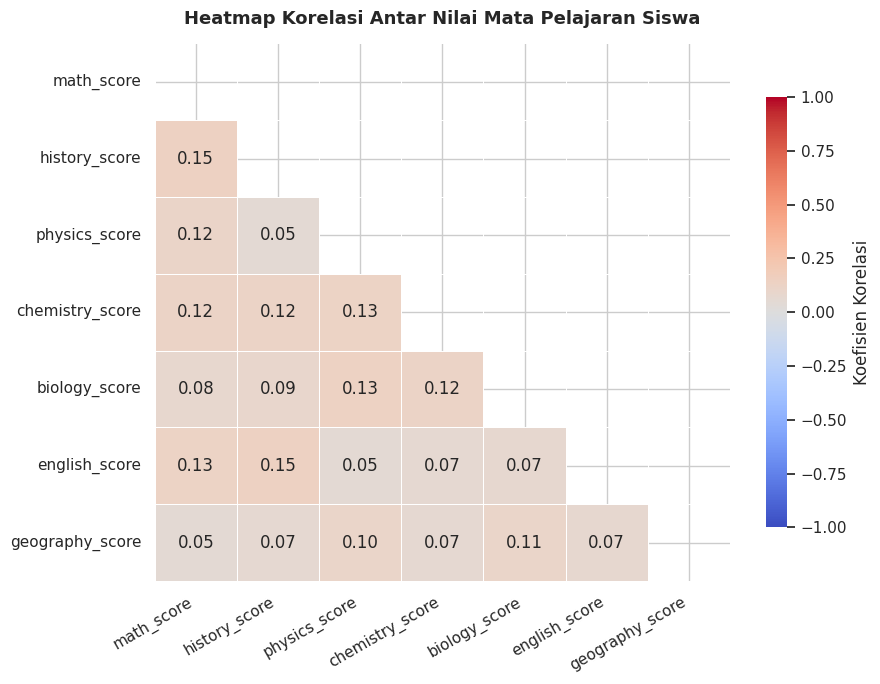

In [24]:
#Visualisasi 1: Heatmap Korelasi
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    ax=ax,
    vmin=-1, vmax=1,
    cbar_kws={'label': 'Koefisien Korelasi', 'shrink': 0.8}
)
ax.set_title(
    'Heatmap Korelasi Antar Nilai Mata Pelajaran Siswa',
    fontsize=13, fontweight='bold', pad=14
)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('output/viz1_heatmap_korelasi.png', bbox_inches='tight')
plt.show()


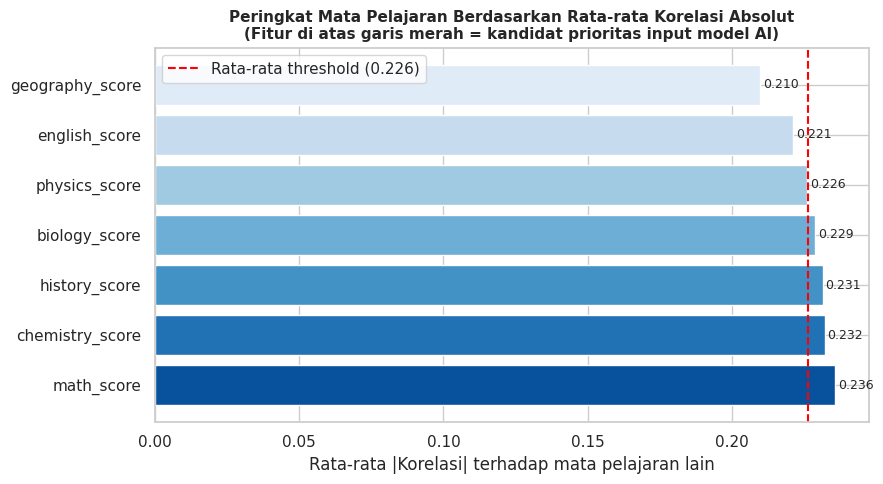

In [25]:
#Visualisasi 2: Bar Plot Rata-Rata Korelasi per Fitur
fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('Blues_r', len(mean_abs_corr))
bars = ax.barh(mean_abs_corr.index, mean_abs_corr.values, color=colors, edgecolor='white')
ax.axvline(x=threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Rata-rata threshold ({threshold:.3f})')
for bar, val in zip(bars, mean_abs_corr.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Rata-rata |Korelasi| terhadap mata pelajaran lain')
ax.set_title(
    'Peringkat Mata Pelajaran Berdasarkan Rata-rata Korelasi Absolut\n'
    '(Fitur di atas garis merah = kandidat prioritas input model AI)',
    fontsize=11, fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.savefig('output/viz2_bar_korelasi.png', bbox_inches='tight')
plt.show()

#### Insight:
1. Heatmap Korelasi:
-  Seluruh koefisien korelasi bernilai positif dan rendah (maksimal 0.15), yang secara visual terlihat dari warna heatmap yang didominasi orange muda tanpa ada sel yang mendekati merah
- Korelasi tertinggi terlihat pada pasangan math-history dan history-english (0.15), sedangkan math-geofraphy memiliki korelasi paling lemah (0.05)
- Tidak ada multikolinearitas antar fitur, sehingga semua mata pelajaran dapat digunakan secara bersamaan dalam pemodelan tanpa risiko redundansi

2. Bar Plot Rata-rata Korelasi Absolur:
- math_score menempati posisi terartas (0.236), diikuti chemistry_score (0.232) dan history_score (0.231), menandakan ketiga fitur ini paling informatif secara relatif
- Garis threshold 0.226 memisahkan 4 fitur prioritas (math, chemistry, history, biology) dari 3 fitur di bawahnya
- geography_score berada paling bawah (0.210), namun selisihnya dengan fitur lain sangat kecil, menunjukkan perbedaan kontribusi antar mata pelajaran secara keseluruhan tidak terlalu signifikan

### Pertanyaan 2:

Apakah perbedaan nilai akademik antar kelompok aspirasi karier cukup signifikan untuk dijadikan dasar klasifikasi otomatis oleh model AI?

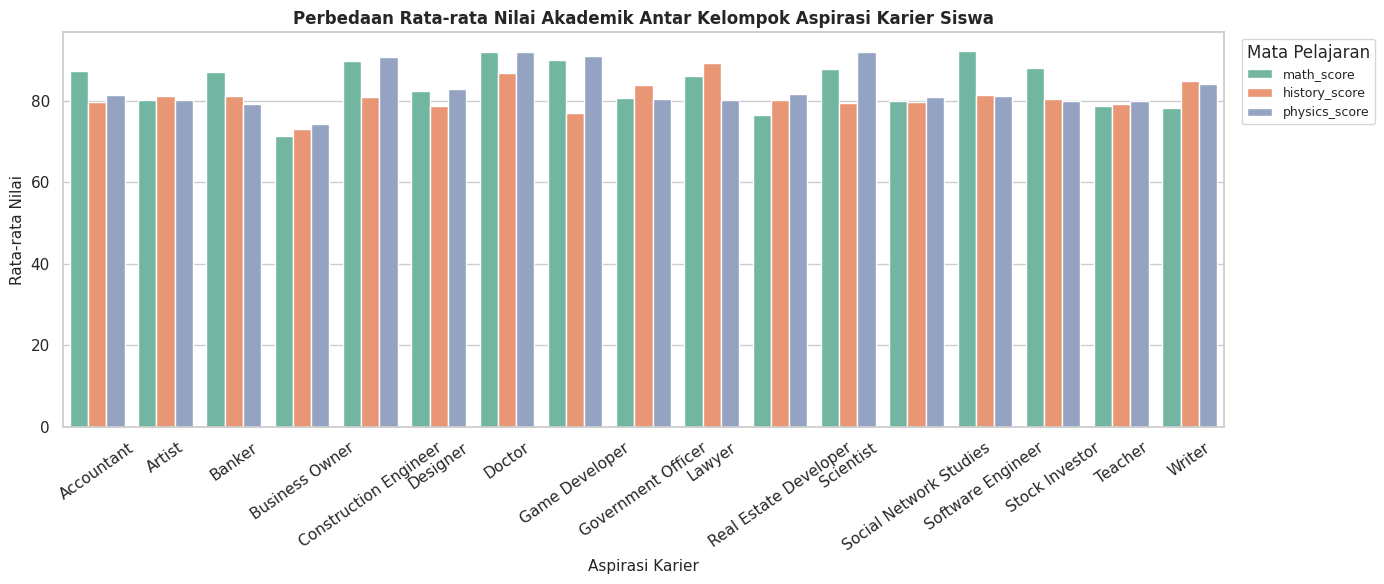

In [26]:
# Visualisasi 3: Grouped Bar Chart Nilai per Aspirasi Karier

# Buat folder output jika belum ada
os.makedirs('output', exist_ok=True)

# Ambil 3 mata pelajaran untuk visualisasi
top_feats_viz = score_cols[:3]

# Hitung rata-rata nilai per aspirasi karier
grouped = (
    scores_clean
    .groupby('career_aspiration')[top_feats_viz]
    .mean()
    .reset_index()
)

# Ubah ke format long
melt = grouped.melt(
    id_vars='career_aspiration',
    var_name='Mata Pelajaran',
    value_name='Rata-rata Nilai'
)

# Plot
fig, ax = plt.subplots(figsize=(14,6))

sns.barplot(
    data=melt,
    x='career_aspiration',
    y='Rata-rata Nilai',
    hue='Mata Pelajaran',
    palette='Set2',
    ax=ax
)

ax.set_xlabel(
    'Aspirasi Karier',
    fontsize=11
)

ax.set_ylabel(
    'Rata-rata Nilai',
    fontsize=11
)

ax.set_title(
    'Perbedaan Rata-rata Nilai Akademik Antar Kelompok Aspirasi Karier Siswa',
    fontsize=12,
    fontweight='bold'
)

ax.tick_params(
    axis='x',
    rotation=35
)

ax.legend(
    title='Mata Pelajaran',
    bbox_to_anchor=(1.01,1),
    loc='upper left',
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    'output/viz3_grouped_bar_jurusan.png',
    bbox_inches='tight'
)

plt.show()

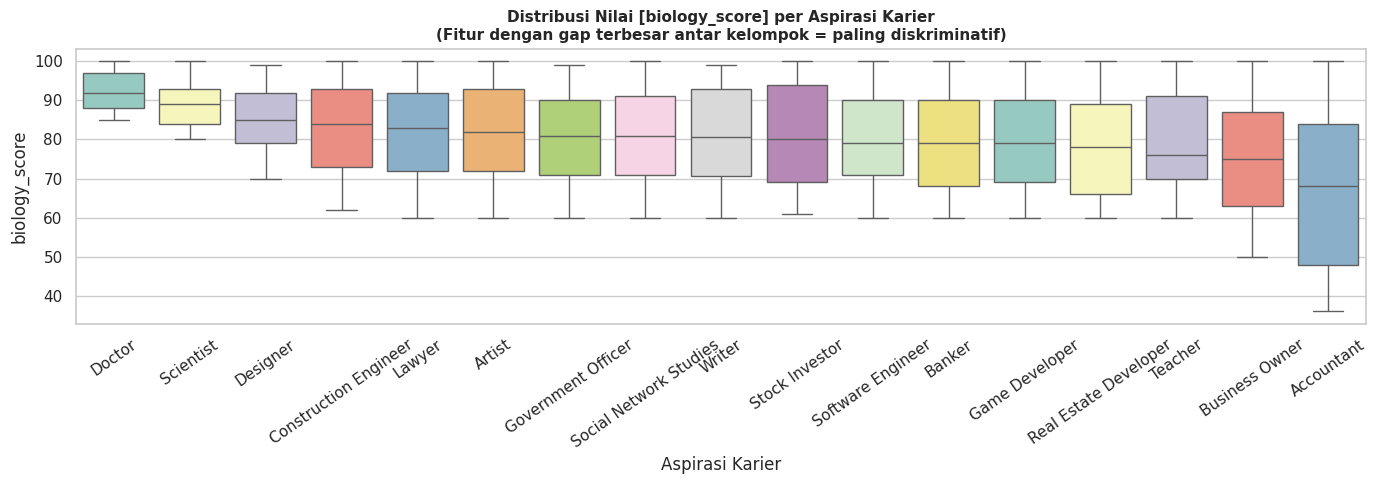

In [27]:
#Visualisasi 4: Boxplot Nilai Fisika per Aspirasi Karier
best_feat = gap.index[0]
order_box = (scores_clean.groupby('career_aspiration')[best_feat]
             .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=scores_clean,
    x='career_aspiration',
    y=best_feat,
    order=order_box,
    palette='Set3',
    ax=ax
)
ax.set_title(
    f'Distribusi Nilai [{best_feat}] per Aspirasi Karier\n'
    '(Fitur dengan gap terbesar antar kelompok = paling diskriminatif)',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Aspirasi Karier')
ax.set_ylabel(best_feat)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('output/viz4_boxplot_jurusan.png', bbox_inches='tight')
plt.show()

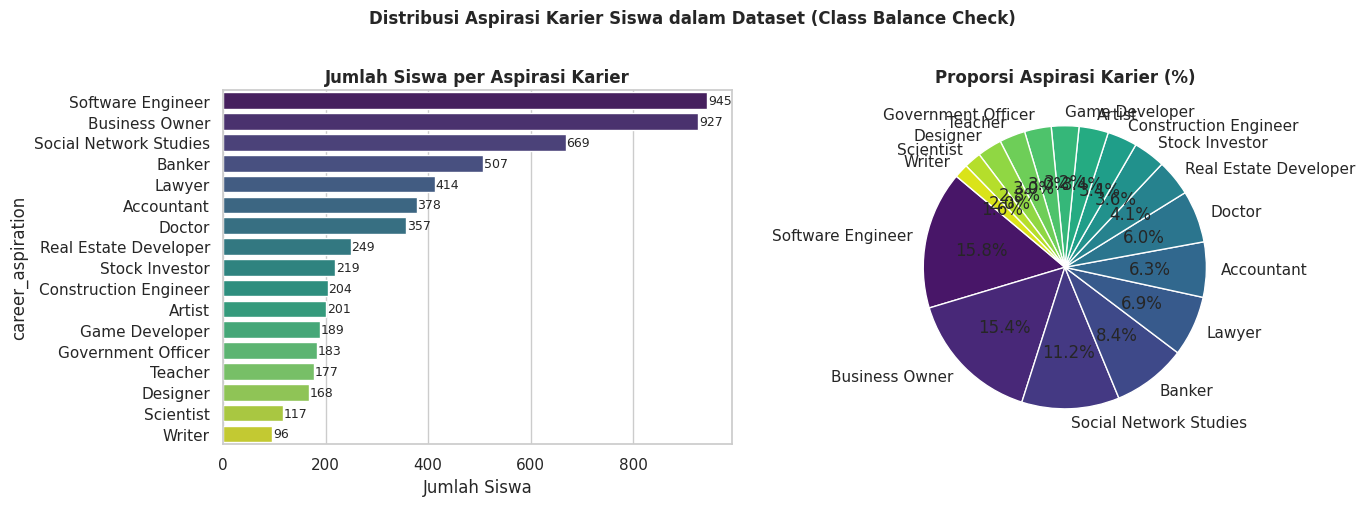

In [28]:
#Visualisasi 5: Distribusi Aspirasi Karier (Class Balance Check)
jurusan_count = scores_clean['career_aspiration'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(
    x=jurusan_count.values,
    y=jurusan_count.index,
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Jumlah Siswa per Aspirasi Karier', fontweight='bold')
axes[0].set_xlabel('Jumlah Siswa')
for i, v in enumerate(jurusan_count.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

axes[1].pie(
    jurusan_count.values,
    labels=jurusan_count.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('viridis', len(jurusan_count))
)

axes[1].set_title('Proporsi Aspirasi Karier (%)', fontweight='bold')

plt.suptitle(
    'Distribusi Aspirasi Karier Siswa dalam Dataset (Class Balance Check)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('output/viz5_distribusi_aspirasi.png', bbox_inches='tight')
plt.show()

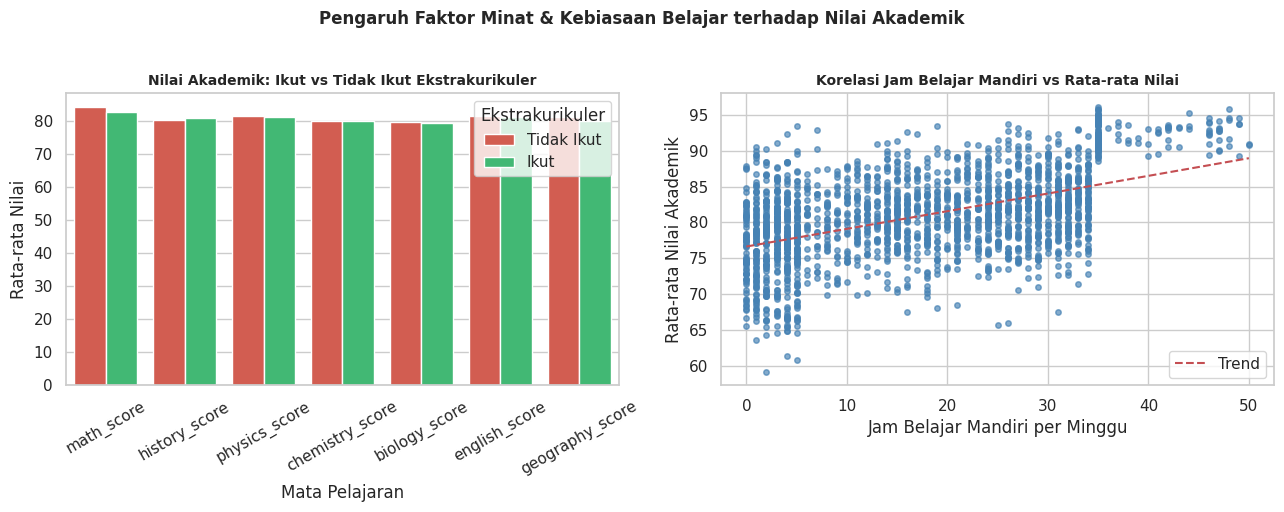

In [29]:
# Visualisasi 6 (Bonus): Pengaruh Ekstrakurikuler terhadap Nilai Akademik

fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Grafik 1: Ekstrakurikuler vs nilai akademik
ekskul_mean = (
    scores_clean
    .groupby('extracurricular_activities')[score_cols]
    .mean()
)

ekskul_melt = ekskul_mean.reset_index().melt(
    id_vars='extracurricular_activities',
    var_name='Mata Pelajaran',
    value_name='Rata-rata Nilai'
)

ekskul_melt['Label'] = ekskul_melt[
    'extracurricular_activities'
].map({
    0: 'Tidak Ikut',
    1: 'Ikut'
})

sns.barplot(
    data=ekskul_melt,
    x='Mata Pelajaran',
    y='Rata-rata Nilai',
    hue='Label',
    palette=['#e74c3c', '#2ecc71'],
    ax=axes[0]
)

axes[0].set_title(
    'Nilai Akademik: Ikut vs Tidak Ikut Ekstrakurikuler',
    fontweight='bold',
    fontsize=10
)

axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Ekstrakurikuler')


# Grafik 2: Jam belajar vs rata-rata nilai
avg_score_temp = scores_clean[score_cols].mean(axis=1)

axes[1].scatter(
    scores_clean['weekly_self_study_hours'],
    avg_score_temp,
    alpha=0.3,
    color='steelblue',
    s=15
)

z = np.polyfit(
    scores_clean['weekly_self_study_hours'],
    avg_score_temp,
    1
)

p = np.poly1d(z)

x_range = np.linspace(
    scores_clean['weekly_self_study_hours'].min(),
    scores_clean['weekly_self_study_hours'].max(),
    100
)

axes[1].plot(
    x_range,
    p(x_range),
    'r--',
    linewidth=1.5,
    label='Trend'
)

axes[1].set_xlabel('Jam Belajar Mandiri per Minggu')
axes[1].set_ylabel('Rata-rata Nilai Akademik')

axes[1].set_title(
    'Korelasi Jam Belajar Mandiri vs Rata-rata Nilai',
    fontweight='bold',
    fontsize=10
)

axes[1].legend()

plt.suptitle(
    'Pengaruh Faktor Minat & Kebiasaan Belajar terhadap Nilai Akademik',
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'output/viz6_minat_vs_nilai.png',
    bbox_inches='tight'
)

plt.show()

#### Insight

1. Grouped Bar Chart
- Terlihat jelas perbedaan rata-rata nilai antar aspirasi karier, Doctor dan Game Developer memiliki math dan physiscs tetinggi, sementara Business Owner konsisten berada di bawah kelompok lain
- Pola ini mengkonfirmasi bahwa nilai akademik cukup informatif untuk membedakan kelompok karier tertentu

2. Boxplot Biology Score
- Doctor memiliki median biology_score tertinggi (~ 92) dengan sebaran sempit, sedangkan Accountant berada paling bawah dengan sebaran sangat lebar hingga mendekati 36
- Sebaran yang berbeda antar kelompok ini memeprkuat bahwa biology_score adalah fitur paling diskriminatif untuk klasifikasi

3. Class Balance Cheek
- Distribusi tidak merata, Software Engineer (15.8%) dan Business Owner (15.4%) mendominasi, sementara Writer (1.6%) dan Scientist (2%) sangat sedikit
- Ketidakseimbangan ini perlu diperhatikan saat pemodelan agar model tidak bias terhadap kelas mayoritas

4. Pengaruh ekstrakurikuler & Jam Belajar
- Siswa yang tidak ikut ekstrakurikuler cenderung memiliki rata-rata nilai sedikit lebih tinggi di hampir semua mata pelajaran, meski selisihnya sangat kecil
- Terdapat tren positif antara jam belajar mandiri dan rata-rata nilai akademik, semakin banyak jam belajar semakin tinggi nilainya meski variasi datanya cukup besar

## Analisis Lanjutan - Feature Engineering

Pada tahap ini dilakukan rekayasa fitur untuk mempersiapkan dataset yang siap digunakan oleh model machine learning di Minggu 4. Fitur-fitur baru dibuat berdasarkan temuan dari proses EDA

In [30]:
df_fe = scores_clean.copy()

#1. Rata-rata nilai keseluruhan
df_fe['average_score'] = df_fe[score_cols].mean(axis=1).round(2)
print(f'[FE 1] average_score dibuat dari rata-rata {len(score_cols)} mata pelajaran ')
print(f' mean={df_fe["average_score"].mean():.2f}, std={df_fe["average_score"].std():.2f}')

# 2. Kategori performa berdasarkan kuartil
q33 = df_fe['average_score'].quantile(0.33)
q66 = df_fe['average_score'].quantile(0.66)
df_fe['performance_category'] = pd.cut(
    df_fe['average_score'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['Rendah', 'Sedang', 'Tinggi']
)
print(f'\n[FE 2] performance_category (Rendah < {q33:.1f} ≤ Sedang < {q66:.1f} ≤ Tinggi):')
print(df_fe['performance_category'].value_counts())

# 3. Domain score (sains & sosial)
sains_cols  = [c for c in ['physics_score','chemistry_score','biology_score','math_score'] if c in df_fe.columns]
sosial_cols = [c for c in ['history_score','geography_score'] if c in df_fe.columns]
df_fe['sains_score']  = df_fe[sains_cols].mean(axis=1).round(2)
df_fe['sosial_score'] = df_fe[sosial_cols].mean(axis=1).round(2)
df_fe['bahasa_score'] = df_fe['english_score']
print(f'\n[FE 3] Domain score dibuat:')
print(f'       sains_score  = rata-rata {sains_cols}')
print(f'       sosial_score = rata-rata {sosial_cols}')
print(f'       bahasa_score = english_score')

# 4. One-Hot Encoding gender
gender_dummies = pd.get_dummies(df_fe['gender'], prefix='gender').astype(int)
df_fe = pd.concat([df_fe, gender_dummies], axis=1)
print(f'\n[FE 4] One-Hot Encoding gender → {gender_dummies.columns.tolist()}')

# 5. Label Encoding career_aspiration
le = LabelEncoder()
df_fe['career_encoded'] = le.fit_transform(df_fe['career_aspiration'])
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print(f'\n[FE 5] Label Encoding career_aspiration → career_encoded:')
for karier, kode in label_map.items():
    print(f'       {int(kode):2d} → {karier}')

# 5b. Mapping career_aspiration -> major_group
major_group_mapping = {
    'Doctor'                : 'Sains & Kesehatan',
    'Scientist'             : 'Sains & Kesehatan',
    'Software Engineer'     : 'Teknologi',
    'Game Developer'        : 'Teknologi',
    'Accountant'            : 'Bisnis & Keuangan',
    'Banker'                : 'Bisnis & Keuangan',
    'Business Owner'        : 'Bisnis & Keuangan',
    'Stock Investor'        : 'Bisnis & Keuangan',
    'Real Estate Developer' : 'Bisnis & Keuangan',
    'Lawyer'                : 'Sosial & Hukum',
    'Government Officer'    : 'Sosial & Hukum',
    'Teacher'               : 'Sosial & Hukum',
    'Social Network Studies': 'Sosial & Hukum',
    'Construction Engineer' : 'Teknik & Konstruksi',
    'Artist'                : 'Seni & Kreatif',
    'Designer'              : 'Seni & Kreatif',
    'Writer'                : 'Seni & Kreatif',
}
df_fe['major_group'] = df_fe['career_aspiration'].map(major_group_mapping)

# 5c. Label Encoding major_group
le_group = LabelEncoder()
df_fe['major_group_encoded'] = le_group.fit_transform(df_fe['major_group'])
label_map_group = dict(zip(le_group.classes_, le_group.transform(le_group.classes_)))
print(f'\n[FE 5b] Mapping career_aspiration → major_group:')
print(df_fe[['career_aspiration','major_group']].drop_duplicates().sort_values('major_group').to_string(index=False))
print(f'\n[FE 5c] Label Encoding major_group → major_group_encoded:')
for grup, kode in label_map_group.items():
    print(f'        {int(kode):2d} → {grup}')

# 6. Normalisasi Min-Max Scaling
cols_to_scale = score_cols + ['average_score','absence_days',
                               'weekly_self_study_hours',
                               'sains_score','sosial_score','bahasa_score']
scaler = MinMaxScaler()
df_scaled = df_fe.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_fe[cols_to_scale])
print(f'\n[FE 6] Min-Max Scaling pada {len(cols_to_scale)} kolom → rentang [0, 1]')

# Simpan dataset final
df_scaled.to_csv('df_ready_for_model.csv', index=False)
print(f'\nDataset final tersimpan: df_ready_for_model.csv')
print(f'Shape: {df_scaled.shape[0]} baris, {df_scaled.shape[1]} kolom')

# Verifikasi jumlah baris
assert df_scaled.shape[0] == 6000, f'WARNING: Ekspektasi 6000 baris, tapi dapat {df_scaled.shape[0]}!'
print('✅ Verifikasi: dataset berisi 6.000 baris - siap untuk modeling')

df_scaled.head()

[FE 1] average_score dibuat dari rata-rata 7 mata pelajaran 
 mean=81.02, std=5.98

[FE 2] performance_category (Rendah < 78.6 ≤ Sedang < 83.1 ≤ Tinggi):
performance_category
Sedang    2010
Tinggi    2007
Rendah    1983
Name: count, dtype: int64

[FE 3] Domain score dibuat:
       sains_score  = rata-rata ['physics_score', 'chemistry_score', 'biology_score', 'math_score']
       sosial_score = rata-rata ['history_score', 'geography_score']
       bahasa_score = english_score

[FE 4] One-Hot Encoding gender → ['gender_Female', 'gender_Male']

[FE 5] Label Encoding career_aspiration → career_encoded:
        0 → Accountant
        1 → Artist
        2 → Banker
        3 → Business Owner
        4 → Construction Engineer
        5 → Designer
        6 → Doctor
        7 → Game Developer
        8 → Government Officer
        9 → Lawyer
       10 → Real Estate Developer
       11 → Scientist
       12 → Social Network Studies
       13 → Software Engineer
       14 → Stock Investor
       

,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,...,major_group,average_score,performance_category,sains_score,sosial_score,bahasa_score,gender_Female,gender_Male,career_encoded,major_group_encoded
0,Male,0,0.3,0,0.54,Lawyer,0.425532,0.62,0.86,0.94,...,Sosial & Hukum,0.617838,Sedang,0.625731,0.651685,0.612245,0,1,9,3
1,Female,0,0.2,0,0.94,Doctor,0.787234,0.72,0.92,1.00,...,Sains & Kesehatan,0.872703,Tinggi,0.918129,0.741573,0.775510,1,0,6,1
2,Female,0,0.9,1,0.26,Government Officer,0.595745,0.94,0.90,0.92,...,Sosial & Hukum,0.737568,Tinggi,0.690058,0.910112,0.551020,1,0,8,3
3,Female,0,0.5,0,0.06,Artist,0.382979,0.48,0.76,0.60,...,Seni & Kreatif,0.528919,Sedang,0.637427,0.561798,0.265306,1,0,1,2
4,Male,0,0.5,0,0.20,Social Network Studies,0.659574,0.54,0.30,0.30,...,Sosial & Hukum,0.413243,Rendah,0.438596,0.483146,0.489796,0,1,12,3


#### Insight:
- average_score dibuat dari rata-rata 7 mata pelajaran dengan mean 81.02 dan std 5.98, memberikan gambaran umum performa akademik tiap siswa dalam satu nilai ringkas
- performance_category membagi siswa menjadi tiga kelompok berdasarkan kuartil distribusinya cukup merata antara Rendah (1.983), Sedang (2.010), dan Tinggi (2.007), menunjukkan tidak ada dominasi kategori tertentu
- Domain score dibuat untuk mengelompokkan mata pelajaran berdasarkan bidang: sains_score (rata-rata physics, chemistry, biology, math), sosial_score (rata-rata history, geography), dan bahasa_score (english_score), sehingga model dapat menangkap kecenderungan akademik per domain
- One-Hot Encoding diterapkan pada kolom gender menghasilkan dua kolom biner gender_Female dan gender_Male, menghindari asumsi ordinal yang muncul jika menggunakan label encoding
- Label Encoding diterapkan pada career_aspiration (17 kelas, kode 0-16) dan major_group (6 kelas, kode 0-5) untuk mengubah target kategorik menjadi format numerik yang dapat diproses model
- Min-Max Scaling diterapkan pada 13 kolom numerik sehingga seluruh nilai berada di rentang [0, 1], mencegah fitur dengan skala besar mendominasi proses pembelajaran model
- Dataset final tersimpan sebagai df_ready_for_model.csv dengan shape 6.000 baris dan 23 kolom, telah diverifikasi dan siap digunakan untuk tahap pemodelan

# Conclusion & Recommendation

## Conclusion
Pertanyaan 1:
Seluruh nilai mata pelajaran memiliki korelasi positif satu sama lain meskipun nilainya rendah (maksimal 0.147). Fitur math_score, chemistry_score,  history_score, dan biology_score merupakan fitur paling informatif karena rata-rata korelasi absolutnya melampaui threshold 0.226, sehingga menjadi kandidat input prioritas untuk model rekomendasi jurusan.

Pertanyaan 2:
Terdapat perbedaan rata-rata nilai akademik yang cukup signifikan antar 17 kelompok aspirasi karier, dengan gap terbesar pada biology_score sebesar 26.46 poin, diikuti math_score (20.87) dan english_score (19.25). Pola ini mengkonfirmasi bahwa nilai akademik memiliki daya diskriminatif yang memadai untuk dijadikan dasar klasifikasi otomatis oleh model AI.

## Recommendation
- Jadikan math_score, chemistry_score, history_score, dan biology_score sebagai input prioritas pada form website karena terbukti paling diskriminatif antar kelompok karier
- Tambahkan input ekstrakurikuler dan jam belajar mandiri pada form website karena visualisasi 6 menunjukkan keduanya berkorelasi positif dengan performa nilai akademik siswa
- Perhatikan class imbalance pada distribusi aspirasi karier karena Software Engineer (15.8%) dan Business Owner (15.4%) mendominasi sementara Writer hanya 1.6% yang dapat mempengaruhi performa model saat pemodelan